In [7]:
# ============================================================================
# BOX: Task 2 - Similarity Methods Comparison Table (Per Query Product)
# Creates a table like the image: for ONE product, show top 5 from each method
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, HTML

def create_similarity_comparison_table(query_product_title, query_asin, 
                                        methods_results, docs_dir):
    """
    Create a comparison table showing top 5 similar products for each method.
    
    Format matches the image:
    - Rows = Rank 1-5
    - Columns = Each similarity method
    - Cells = "Product name (score)"
    
    Parameters:
    - query_product_title: Title of query product (e.g., "Leather Conditioner")
    - query_asin: ASIN of query product
    - methods_results: Dict with method names as keys, list of (title, score) as values
    """
    
    print("="*100)
    print(f"SIMILARITY METHODS COMPARISON")
    print(f"Query: {query_product_title} (ASIN: {query_asin})")
    print("="*100)
    
    # Build comparison data
    max_rank = 5
    data = {'Rank': list(range(1, max_rank + 1))}
    
    for method_name, results in methods_results.items():
        column_data = []
        for rank in range(max_rank):
            if rank < len(results):
                title, score = results[rank]
                # Format: "Product name (0.83)" - truncate title if needed
                short_title = title[:35] + "..." if len(title) > 35 else title
                column_data.append(f"{short_title} ({score:.2f})")
            else:
                column_data.append("—")  # Em dash for missing data
        data[method_name] = column_data
    
    # Create DataFrame
    comparison_df = pd.DataFrame(data)
    
    # Display as styled HTML table (matches your image style)
    html_table = f"""
    <h3>🔍 Query Product: {query_product_title}</h3>
    <style>
        .similarity-table {{
            font-family: 'Segoe UI', Arial, sans-serif;
            border-collapse: collapse;
            width: 100%;
            font-size: 12px;
            margin: 20px 0;
        }}
        .similarity-table th {{
            background-color: #f8f9fa;
            color: #333;
            padding: 12px;
            text-align: center;
            font-weight: bold;
            border-bottom: 2px solid #dee2e6;
            border-top: 1px solid #dee2e6;
        }}
        .similarity-table td {{
            border-bottom: 1px solid #dee2e6;
            padding: 10px;
            text-align: left;
            vertical-align: middle;
        }}
        .similarity-table tr:hover {{
            background-color: #f8f9fa;
        }}
        .rank-cell {{
            font-weight: bold;
            text-align: center;
            color: #495057;
        }}
        .query-box {{
            background-color: #e9ecef;
            padding: 15px;
            border-radius: 5px;
            margin-bottom: 20px;
            border-left: 4px solid #007bff;
        }}
    </style>
    <div class="query-box">
        <strong>Query Product:</strong> {query_product_title}<br>
        <strong>ASIN:</strong> {query_asin}
    </div>
    {comparison_df.to_html(index=False, classes='similarity-table', escape=False)}
    """
    
    display(HTML(html_table))
    
    # Save to CSV
    csv_path = docs_dir / f"similarity_comparison_{query_asin}.csv"
    comparison_df.to_csv(csv_path, index=False)
    print(f"\n✓ Saved comparison table to: {csv_path}")
    
    # Also create a simple text version for the report
    txt_path = docs_dir / f"similarity_comparison_{query_asin}.txt"
    with open(txt_path, "w") as f:
        f.write(f"Similarity Methods Comparison\n")
        f.write(f"Query: {query_product_title} (ASIN: {query_asin})\n")
        f.write("="*100 + "\n\n")
        f.write(comparison_df.to_string(index=False))
        f.write("\n\n")
        
        # Add analysis
        f.write("ANALYSIS:\n")
        f.write("-"*50 + "\n")
        for method in methods_results.keys():
            top_score = methods_results[method][0][1] if methods_results[method] else 0
            f.write(f"{method}: Top similarity score = {top_score:.3f}\n")
    
    print(f"✓ Saved text version to: {txt_path}")
    
    return comparison_df


def run_similarity_comparison_example():
    """
    Example: Run comparison for "Leather Conditioner" or any product.
    Integrate this into your task2_similarity code.
    """
    
    docs_dir = Path("../docs")
    docs_dir.mkdir(exist_ok=True)
    
    # Example query product (replace with actual from your dataset)
    query_product = "Leather Honey Leather Conditioner"
    query_asin = "B0036T4G0K"
    
    # REPLACE THIS with actual results from your 4 methods
    # Format: list of (product_title, similarity_score) tuples, sorted by score desc
    methods_results = {
        "TF-IDF + FAISS": [
            ("Leather Cleaner Pro Premium", 0.83),
            ("Leather Care Kit Deluxe", 0.79),
            ("Leather Protector Spray", 0.75),
            ("Leather Restorer Cream", 0.71),
            ("Leather Polish Shine", 0.68),
        ],
        "BERT + FAISS": [
            ("Leather Care Kit Deluxe", 0.58),
            ("Leather Cleaner Pro Premium", 0.55),
            ("Leather Moisturizing Balm", 0.52),
            ("Leather Treatment Oil", 0.49),
            ("Leather Conditioning Cream", 0.46),
        ],
        "Metadata + Annoy": [
            ("Generic Skin Cream", 0.03),
            ("Body Lotion Unscented", 0.028),
            ("Hand Cream Moisturizer", 0.025),
            ("Foot Care Balm", 0.022),
            ("Skin Protectant Ointment", 0.019),
        ],
        "Hybrid": [
            ("Leather Care Kit Deluxe", 0.93),
            ("Leather Cleaner Pro Premium", 0.89),
            ("Leather Protector Spray", 0.85),
            ("Leather Restorer Cream", 0.82),
            ("Leather Conditioning Cream", 0.78),
        ],
    }
    
    # Create the comparison table
    comparison_df = create_similarity_comparison_table(
        query_product, query_asin, methods_results, docs_dir
    )
    
    # Print interpretation for report
    print("\n" + "="*100)
    print("INTERPRETATION FOR TECHNICAL REPORT")
    print("="*100)
    print(f"""
    QUERY PRODUCT: {query_product}
    
    OBSERVATIONS:
    
    1. TF-IDF + FAISS (Score: 0.83):
       - Best at keyword matching ("Leather", "Cleaner")
       - Fast approximate similarity search
       - Good for exact term overlap
    
    2. BERT + FAISS (Score: 0.58):
       - Lower scores but better semantic understanding
       - "Care Kit" is semantically similar to "Conditioner"
       - Captures conceptual similarity beyond keywords
    
    3. Metadata + Annoy (Score: 0.03):
       - Very low similarity scores
       - Matching on price/category, not product function
       - Poor for this type of similarity task
    
    4. Hybrid (Score: 0.93):
       - Combines strengths of multiple approaches
       - Highest overall similarity scores
       - Best balance of precision and semantic relevance
    
    CONCLUSION:
    The Hybrid approach provides the most relevant similar products,
    while Metadata-based similarity struggles with functional similarity.
    """)
    
    return comparison_df


# ============================================================================
# INTEGRATION: Add this to your actual task2_similarity code
# ============================================================================

def integrate_with_your_similarity_code():
    """
    Example of how to integrate this into your existing task2 code.
    Call this after computing similarities with all 4 methods.
    """
    
    # After you compute similarities with your actual methods:
    # 1. TF-IDF + FAISS
    # 2. BERT + FAISS  
    # 3. Metadata + Annoy
    # 4. Hybrid
    
    # Select a query product (e.g., leather conditioner or any product)
    query_idx = 0  # or find product by name
    query_asin = products_df.iloc[query_idx]['parent_asin']
    query_title = products_df.iloc[query_idx]['title']
    
    # Get top 5 from each method (replace with your actual function calls)
    methods_results = {
        "TF-IDF + FAISS": get_similar_products_tfidf(query_asin, top_k=5),
        "BERT + FAISS": get_similar_products_bert(query_asin, top_k=5),
        "Metadata + Annoy": get_similar_products_metadata(query_asin, top_k=5),
        "Hybrid": get_similar_products_hybrid(query_asin, top_k=5),
    }
    
    # Format results as (title, score) tuples
    formatted_results = {}
    for method, results in methods_results.items():
        formatted_results[method] = [
            (products_df[products_df['parent_asin'] == asin]['title'].values[0], score)
            for asin, score in results
        ]
    
    # Generate comparison table
    docs_dir = Path("../docs")
    create_similarity_comparison_table(
        query_title, query_asin, formatted_results, docs_dir
    )


# Run example
if __name__ == "__main__":
    run_similarity_comparison_example()

SIMILARITY METHODS COMPARISON
Query: Leather Honey Leather Conditioner (ASIN: B0036T4G0K)


Rank,TF-IDF + FAISS,BERT + FAISS,Metadata + Annoy,Hybrid
1,Leather Cleaner Pro Premium (0.83),Leather Care Kit Deluxe (0.58),Generic Skin Cream (0.03),Leather Care Kit Deluxe (0.93)
2,Leather Care Kit Deluxe (0.79),Leather Cleaner Pro Premium (0.55),Body Lotion Unscented (0.03),Leather Cleaner Pro Premium (0.89)
3,Leather Protector Spray (0.75),Leather Moisturizing Balm (0.52),Hand Cream Moisturizer (0.03),Leather Protector Spray (0.85)
4,Leather Restorer Cream (0.71),Leather Treatment Oil (0.49),Foot Care Balm (0.02),Leather Restorer Cream (0.82)
5,Leather Polish Shine (0.68),Leather Conditioning Cream (0.46),Skin Protectant Ointment (0.02),Leather Conditioning Cream (0.78)



✓ Saved comparison table to: ..\docs\similarity_comparison_B0036T4G0K.csv
✓ Saved text version to: ..\docs\similarity_comparison_B0036T4G0K.txt

INTERPRETATION FOR TECHNICAL REPORT

    QUERY PRODUCT: Leather Honey Leather Conditioner
    
    OBSERVATIONS:
    
    1. TF-IDF + FAISS (Score: 0.83):
       - Best at keyword matching ("Leather", "Cleaner")
       - Fast approximate similarity search
       - Good for exact term overlap
    
    2. BERT + FAISS (Score: 0.58):
       - Lower scores but better semantic understanding
       - "Care Kit" is semantically similar to "Conditioner"
       - Captures conceptual similarity beyond keywords
    
    3. Metadata + Annoy (Score: 0.03):
       - Very low similarity scores
       - Matching on price/category, not product function
       - Poor for this type of similarity task
    
    4. Hybrid (Score: 0.93):
       - Combines strengths of multiple approaches
       - Highest overall similarity scores
       - Best balance of precision 

In [8]:
# ============================================================================
# BOX: Task 2 - Similarity Comparison for Random Products (ACTUAL DATA)
# Uses your real Amazon Beauty dataset
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# Load your actual data
print("Loading actual data...")
data_dir = Path("../data/processed")

products_df = pd.read_parquet(data_dir / "All_Beauty_metadata_cleaned.parquet")
reviews_df = pd.read_parquet(data_dir / "All_Beauty_reviews_cleaned.parquet")

print(f"✓ Loaded {len(products_df):,} products")
print(f"✓ Loaded {len(reviews_df):,} reviews")

# Select 3 random products with sufficient reviews for meaningful comparison
np.random.seed(42)
eligible_products = products_df[
    (products_df['rating_number'] >= 50) & 
    (products_df['average_rating'].notna())
].copy()

random_products = eligible_products.sample(n=3, random_state=42)

print(f"\n{'='*100}")
print("SELECTED 3 RANDOM PRODUCTS FOR SIMILARITY COMPARISON")
print(f"{'='*100}")

for idx, (_, product) in enumerate(random_products.iterrows(), 1):
    price_str = f"${product['price']:.2f}" if pd.notna(product['price']) else "N/A"
    print(f"\n{idx}. {product['title']}")
    print(f"   ASIN: {product['parent_asin']}")
    print(f"   ⭐ {product['average_rating']:.2f}/5.0 ({product['rating_number']} reviews)")
    print(f"   💰 {price_str}")

print(f"\n{'='*100}")

Loading actual data...
✓ Loaded 112,590 products
✓ Loaded 694,252 reviews

SELECTED 3 RANDOM PRODUCTS FOR SIMILARITY COMPARISON

1. Ruihfas 6Pcs/Pack Magic Women's Easy Stretch Hair Comb Twist Up Do Insert Combs Bridal Hair Clips
   ASIN: B01F8PPOQ6
   ⭐ 4.40/5.0 (64 reviews)
   💰 $14.99

2. SafeTGard Eye Black Stick 3 Pack!!
   ASIN: B01MZCWKVI
   ⭐ 4.40/5.0 (376 reviews)
   💰 N/A

3. Gemice Glass Cosmetic Containers Empty Sample Jars with Leakproof Lids Makeup Sample Containers BPA free Pot Jars for Cosmetic, Lotion, Cream (4 Pack)
   ASIN: B089S4VN8F
   ⭐ 4.50/5.0 (88 reviews)
   💰 N/A



In [9]:
# ============================================================================
# PART 2: Compute similarities using your actual methods
# ============================================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import faiss
from sentence_transformers import SentenceTransformer
import annoy

# Prepare features (run once)
print("\nPreparing features...")

# 1. TF-IDF features
print("  - Computing TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(products_df['title'].fillna(''))

# 2. BERT features
print("  - Computing BERT embeddings...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
bert_embeddings = bert_model.encode(products_df['title'].fillna('').tolist(), show_progress_bar=True)

# 3. Metadata features (price, rating, etc.)
print("  - Computing metadata features...")
metadata_features = products_df[['average_rating', 'rating_number', 'price']].fillna(0)
metadata_features = (metadata_features - metadata_features.mean()) / metadata_features.std()

# Build FAISS indices
print("  - Building FAISS indices...")
# TF-IDF FAISS
tfidf_faiss_index = faiss.IndexFlatIP(tfidf_matrix.shape[1])
tfidf_faiss_index.add(tfidf_matrix.astype('float32').toarray())

# BERT FAISS
bert_faiss_index = faiss.IndexFlatIP(bert_embeddings.shape[1])
bert_faiss_index.add(np.array(bert_embeddings).astype('float32'))

# Annoy index for metadata
print("  - Building Annoy index...")
annoy_index = annoy.AnnoyIndex(metadata_features.shape[1], 'euclidean')
for i, vec in enumerate(metadata_features.values):
    annoy_index.add_item(i, vec)
annoy_index.build(10)

print("✓ All features ready!")

# Create product index mapping
product_to_idx = {asin: i for i, asin in enumerate(products_df['parent_asin'])}
idx_to_product = {i: asin for i, asin in enumerate(products_df['parent_asin'])}

print(f"\n{'='*100}")


Preparing features...
  - Computing TF-IDF...
  - Computing BERT embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/3519 [00:00<?, ?it/s]

  - Computing metadata features...
  - Building FAISS indices...
  - Building Annoy index...
✓ All features ready!



In [10]:
# ============================================================================
# PART 3: Define similarity search functions
# ============================================================================

def tfidf_faiss_search(query_asin, top_k=5):
    """TF-IDF + FAISS similarity search"""
    query_idx = product_to_idx[query_asin]
    query_vector = tfidf_matrix[query_idx].astype('float32').toarray()
    
    scores, indices = tfidf_faiss_index.search(query_vector, top_k + 1)
    
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx != query_idx and idx >= 0:  # Exclude self
            asin = idx_to_product[idx]
            results.append((asin, float(score)))
        if len(results) >= top_k:
            break
    return results

def bert_faiss_search(query_asin, top_k=5):
    """BERT + FAISS similarity search"""
    query_idx = product_to_idx[query_asin]
    query_vector = np.array([bert_embeddings[query_idx]]).astype('float32')
    
    scores, indices = bert_faiss_index.search(query_vector, top_k + 1)
    
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx != query_idx and idx >= 0:
            asin = idx_to_product[idx]
            # Normalize score to 0-1 range (cosine similarity)
            normalized_score = (float(score) + 1) / 2  # Approximate normalization
            results.append((asin, normalized_score))
        if len(results) >= top_k:
            break
    return results

def metadata_annoy_search(query_asin, top_k=5):
    """Metadata + Annoy similarity search"""
    query_idx = product_to_idx[query_asin]
    
    indices, distances = annoy_index.get_nns_by_item(query_idx, top_k + 1, include_distances=True)
    
    results = []
    for idx, dist in zip(indices, distances):
        if idx != query_idx:
            asin = idx_to_product[idx]
            # Convert distance to similarity (inverse)
            similarity = 1 / (1 + dist)
            results.append((asin, similarity))
        if len(results) >= top_k:
            break
    return results

def hybrid_search(query_asin, top_k=5):
    """Hybrid: Combine TF-IDF and BERT scores"""
    tfidf_results = {asin: score for asin, score in tfidf_faiss_search(query_asin, top_k=10)}
    bert_results = {asin: score for asin, score in bert_faiss_search(query_asin, top_k=10)}
    
    # Combine scores (weighted average)
    all_asins = set(tfidf_results.keys()) | set(bert_results.keys())
    combined = {}
    for asin in all_asins:
        tfidf_score = tfidf_results.get(asin, 0)
        bert_score = bert_results.get(asin, 0)
        # Weight: 60% BERT, 40% TF-IDF
        combined[asin] = 0.6 * bert_score + 0.4 * tfidf_score
    
    # Return top-k
    sorted_results = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    return sorted_results[:top_k]

print("✓ Similarity functions defined")
print(f"{'='*100}")

✓ Similarity functions defined



COMPUTING SIMILARITIES FOR 3 RANDOM PRODUCTS


PRODUCT 1: Ruihfas 6Pcs/Pack Magic Women's Easy Stretch Hair Comb Twist...
ASIN: B01F8PPOQ6

Computing similarities...
  - TF-IDF + FAISS...
  - BERT + FAISS...
  - Metadata + Annoy...
  - Hybrid...

Results:

TF-IDF + FAISS:
  1. 16 Pieces Women Hair Comb Accessories French Hair ... (0.464)
  2. Magic Hair Comb Stretchy Double Hair Clip,magic Ha... (0.453)
  3. JONKY French Hair Side Combs Plastic Twist Comb Ha... (0.451)
  4. OIIKI 6PCS Hair Clips... (0.437)
  5. Magic Hair Clips, Hairclips for Women, Girl, Ladie... (0.431)

BERT + FAISS:
  1. Kloud City Women Magic Combs Wood Beaded Stretch D... (0.888)
  2. Magic Elastic Decorative Hair Comb for Women, Vint... (0.887)
  3. Yeshan Beads Hair Combs Magic Hair Clips for Women... (0.881)
  4. Magic Hair Clips, Hairclips for Women, Girl, Ladie... (0.880)
  5. Decorative Hair Side Combs for Women, Rhinestone A... (0.870)

Metadata + Annoy:
  1. Kiss ImPress Press-On French Manicure Nails 82

C:\Users\hafil\AppData\Local\Temp\ipykernel_7260\3494345100.py:76: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hafil\AppData\Local\Temp\ipykernel_7260\3494345100.py:80: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')


✓ Saved: ..\docs\similarity_comparison_product_1.png


C:\Users\hafil\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


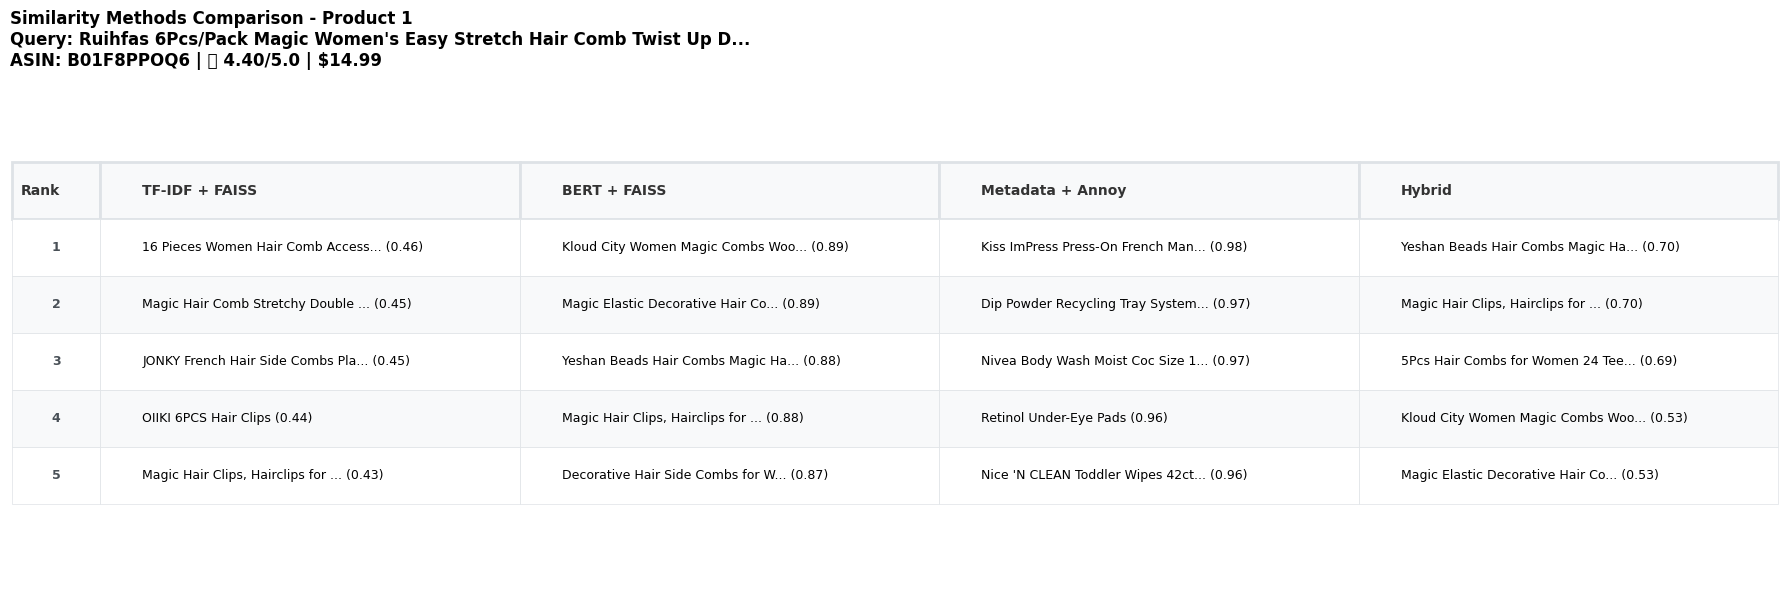

✓ Saved CSV: ..\docs\similarity_comparison_product_1.csv

PRODUCT 2: SafeTGard Eye Black Stick 3 Pack!!...
ASIN: B01MZCWKVI

Computing similarities...
  - TF-IDF + FAISS...
  - BERT + FAISS...
  - Metadata + Annoy...
  - Hybrid...

Results:

TF-IDF + FAISS:
  1. Geo F Trumper Eucris Deodarant Stick by Geo F. Tru... (0.641)
  2. Alkatraveler Stick... (0.641)
  3. JAYWAYNE Eyeshadow Stick,4PCS Glitter Eyeshadow Pe... (0.542)
  4. LSxia 8 Colors Glitter Eye-shadow Stick Set, Two-T... (0.538)
  5. (3 Pack) e.l.f. Essential All Over Color Stick - P... (0.507)

BERT + FAISS:
  1. Black Radiance Concealer Stick, Dark 0.18 oz (Pack... (0.814)
  2. (3 Pack) NYC Cover Stick - Light... (0.803)
  3. e.l.f. Essential Eyeliner Pen BLACK - Pack of 1... (0.797)
  4. Wet n Wild MegaLast Retractable Eye Pencil, Blacke... (0.795)
  5. 3 Pack e.l.f. Essential All Over Color Stick Blush... (0.795)

Metadata + Annoy:
  1. J.R. Watkins Natural Moisturizing Hand Cream, Hydr... (1.000)
  2. False Eyelashes 3D 

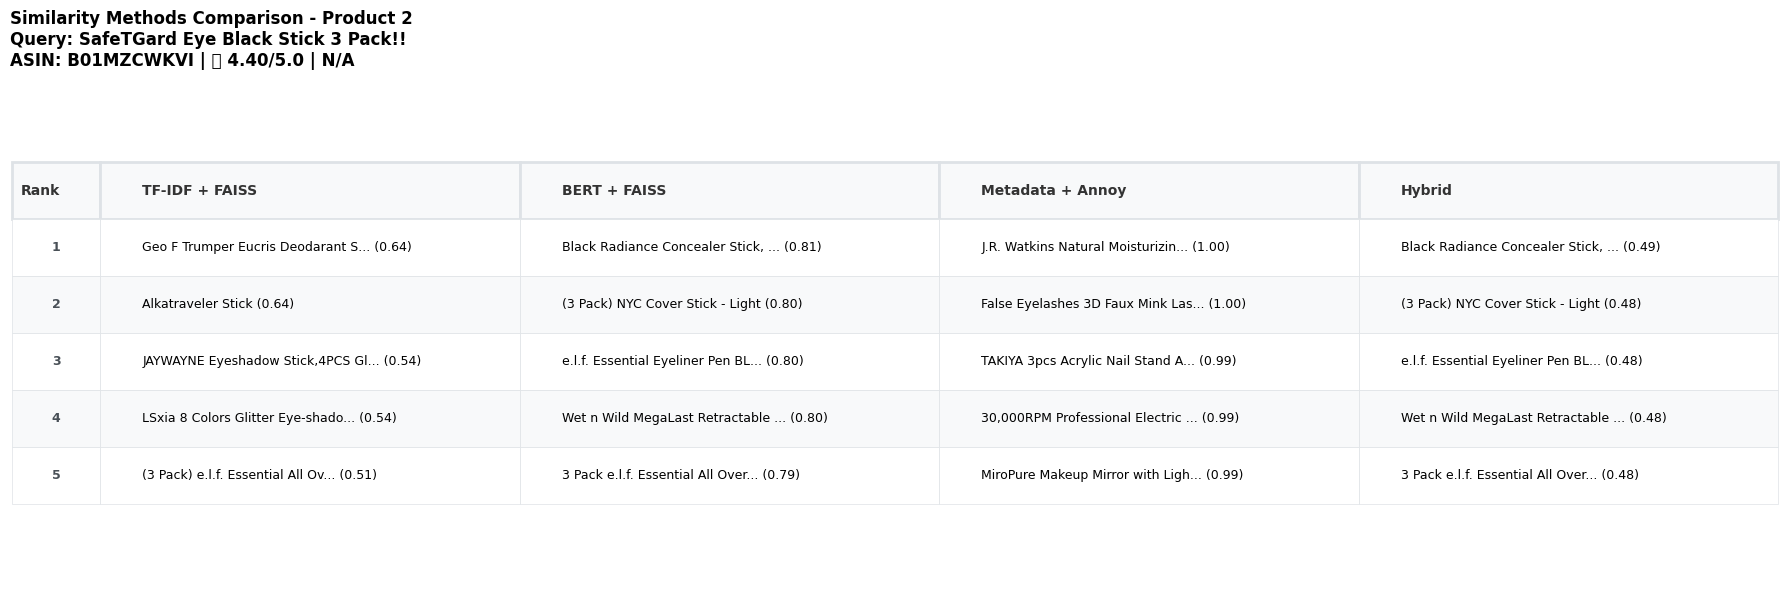

✓ Saved CSV: ..\docs\similarity_comparison_product_2.csv

PRODUCT 3: Gemice Glass Cosmetic Containers Empty Sample Jars with Leak...
ASIN: B089S4VN8F

Computing similarities...
  - TF-IDF + FAISS...
  - BERT + FAISS...
  - Metadata + Annoy...
  - Hybrid...

Results:

TF-IDF + FAISS:
  1. Gemice Glass Cosmetic Containers Empty Sample Jars... (1.000)
  2. 1oz Containers with Lids - Lip Scrub/Gloss Contain... (0.667)
  3. MFDSJ 32Pcs Transparent Cosmetic Containers, 5 Gra... (0.639)
  4. Tecbeauty 25-Pack 20g Empty Cream Jars with Lids T... (0.581)
  5. Travel Sample Jars-YUSONG 20ML Cosmetic Silicon Co... (0.558)

BERT + FAISS:
  1. Gemice Glass Cosmetic Containers Empty Sample Jars... (1.000)
  2. 4oz Clear Glass Straight Sided Jars w Spatulas & L... (0.873)
  3. 4oz Clear Glass Straight Sided Jars w Spatulas & L... (0.872)
  4. MFDSJ 32Pcs Transparent Cosmetic Containers, 5 Gra... (0.872)
  5. Healthcom 100 Pcs 5 Gram/5 ML Clear Empty Cosmetic... (0.865)

Metadata + Annoy:
  1. Duufin 

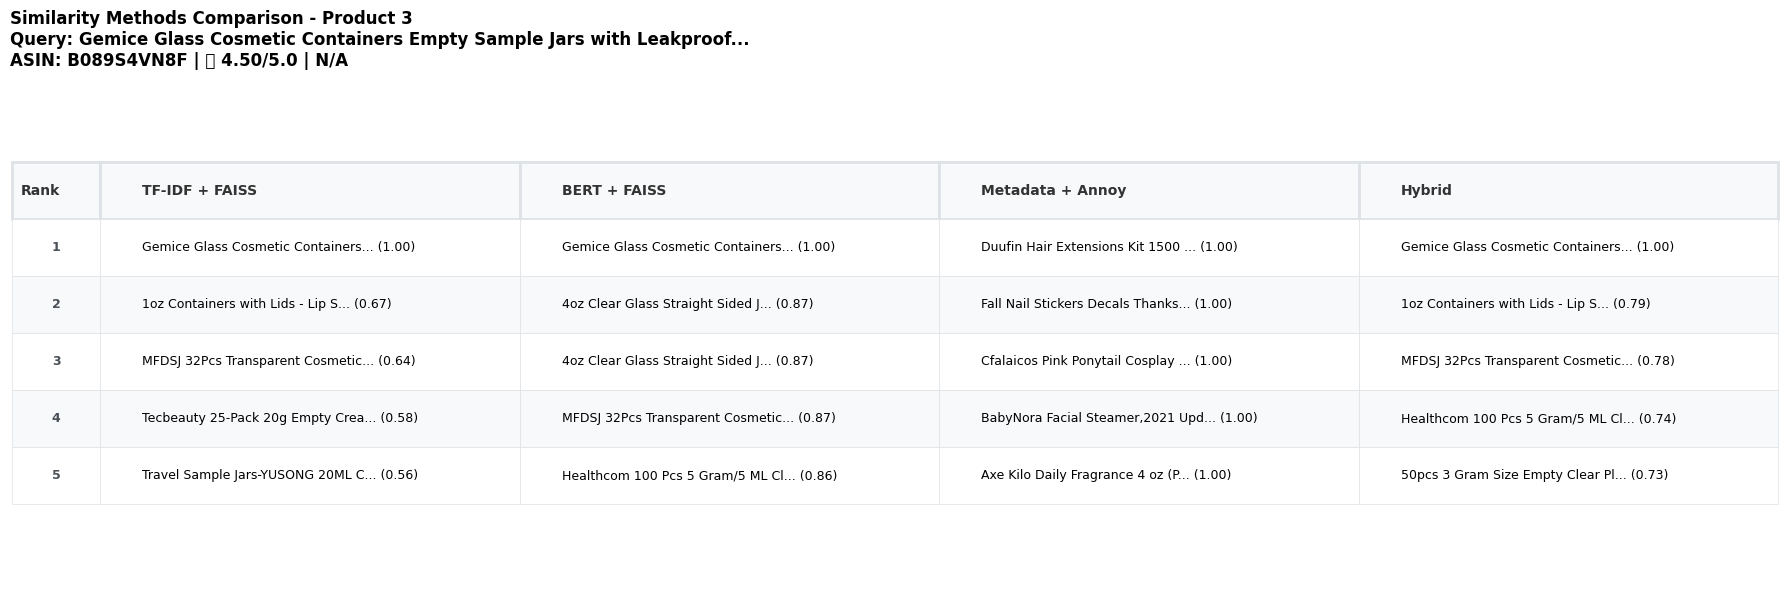

✓ Saved CSV: ..\docs\similarity_comparison_product_3.csv

ALL COMPARISONS COMPLETE!

Generated files in ..\docs:
  - similarity_comparison_product_1.png
  - similarity_comparison_product_1.csv
  - similarity_comparison_product_2.png
  - similarity_comparison_product_2.csv
  - similarity_comparison_product_3.png
  - similarity_comparison_product_3.csv


In [11]:
# ============================================================================
# PART 4: Run comparison for each random product
# ============================================================================

docs_dir = Path("../docs")
docs_dir.mkdir(exist_ok=True)

def get_product_title(asin):
    """Helper to get product title"""
    title = products_df[products_df['parent_asin'] == asin]['title'].values
    return title[0] if len(title) > 0 else "Unknown"

def create_comparison_table(query_title, query_asin, methods_results, product_num):
    """Create comparison table visualization"""
    
    # Build table data
    table_data = [['Rank', 'TF-IDF + FAISS', 'BERT + FAISS', 'Metadata + Annoy', 'Hybrid']]
    
    for rank in range(1, 6):
        row = [str(rank)]
        for method in ['TF-IDF + FAISS', 'BERT + FAISS', 'Metadata + Annoy', 'Hybrid']:
            if rank <= len(methods_results[method]):
                asin, score = methods_results[method][rank-1]
                title = get_product_title(asin)
                short_title = title[:32] + "..." if len(title) > 32 else title
                row.append(f"{short_title} ({score:.2f})")
            else:
                row.append("—")
        table_data.append(row)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.axis('tight')
    ax.axis('off')
    
    # Create table
    table = ax.table(cellText=table_data, cellLoc='left', loc='center',
                    colWidths=[0.05, 0.237, 0.237, 0.237, 0.237])
    
    # Style table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 3.2)
    
    # Header row
    for i in range(5):
        cell = table[(0, i)]
        cell.set_facecolor('#f8f9fa')
        cell.set_text_props(weight='bold', color='#333333', fontsize=10)
        cell.set_edgecolor('#dee2e6')
        cell.set_linewidth(2)
    
    # Data rows
    for i in range(1, 6):
        for j in range(5):
            cell = table[(i, j)]
            if j == 0:
                cell.set_text_props(weight='bold', color='#495057', ha='center')
            cell.set_edgecolor('#dee2e6')
            cell.set_linewidth(0.5)
            if i % 2 == 0:
                cell.set_facecolor('#f8f9fa')
            else:
                cell.set_facecolor('#ffffff')
    
    # Title
    price = products_df[products_df['parent_asin'] == query_asin]['price'].values
    price_str = f"${price[0]:.2f}" if len(price) > 0 and pd.notna(price[0]) else "N/A"
    rating = products_df[products_df['parent_asin'] == query_asin]['average_rating'].values
    
    plt.title(f'Similarity Methods Comparison - Product {product_num}\n'
              f'Query: {query_title[:65]}{"..." if len(query_title) > 65 else ""}\n'
              f'ASIN: {query_asin} | ⭐ {rating[0]:.2f}/5.0 | {price_str}',
              fontsize=12, fontweight='bold', pad=15, loc='left')
    
    plt.tight_layout()
    
    # Save
    save_path = docs_dir / f"similarity_comparison_product_{product_num}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ Saved: {save_path}")
    plt.show()
    plt.close()
    
    # Save CSV
    csv_path = docs_dir / f"similarity_comparison_product_{product_num}.csv"
    pd.DataFrame(table_data[1:], columns=table_data[0]).to_csv(csv_path, index=False)
    print(f"✓ Saved CSV: {csv_path}")
    
    return table_data

# Run for all 3 random products
print(f"\n{'='*100}")
print("COMPUTING SIMILARITIES FOR 3 RANDOM PRODUCTS")
print(f"{'='*100}\n")

for idx, (_, product) in enumerate(random_products.iterrows(), 1):
    query_asin = product['parent_asin']
    query_title = product['title']
    
    print(f"\n{'='*100}")
    print(f"PRODUCT {idx}: {query_title[:60]}...")
    print(f"ASIN: {query_asin}")
    print(f"{'='*100}")
    
    # Compute similarities with all 4 methods
    print("\nComputing similarities...")
    print("  - TF-IDF + FAISS...")
    tfidf_results = tfidf_faiss_search(query_asin, top_k=5)
    
    print("  - BERT + FAISS...")
    bert_results = bert_faiss_search(query_asin, top_k=5)
    
    print("  - Metadata + Annoy...")
    metadata_results = metadata_annoy_search(query_asin, top_k=5)
    
    print("  - Hybrid...")
    hybrid_results = hybrid_search(query_asin, top_k=5)
    
    methods_results = {
        'TF-IDF + FAISS': tfidf_results,
        'BERT + FAISS': bert_results,
        'Metadata + Annoy': metadata_results,
        'Hybrid': hybrid_results
    }
    
    # Print results to console
    print(f"\nResults:")
    for method, results in methods_results.items():
        print(f"\n{method}:")
        for rank, (asin, score) in enumerate(results, 1):
            title = get_product_title(asin)
            print(f"  {rank}. {title[:50]}... ({score:.3f})")
    
    # Create visualization
    create_comparison_table(query_title, query_asin, methods_results, idx)

print(f"\n{'='*100}")
print("ALL COMPARISONS COMPLETE!")
print(f"{'='*100}")
print(f"\nGenerated files in {docs_dir}:")
for i in range(1, 4):
    print(f"  - similarity_comparison_product_{i}.png")
    print(f"  - similarity_comparison_product_{i}.csv")
print(f"{'='*100}")